In [ ]:
from google.colab import drive
import os

print("1. Mounting Google Drive...")
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/MOT17.zip'
extract_path = '/content/assignment_code'

print("2. Unzipping Professor's Toolkit...")
os.makedirs(extract_path, exist_ok=True)
!unzip -q "{zip_path}" -d "{extract_path}"

print("3. Installing Requirements...")

req_file = os.path.join(extract_path, 'requirements.txt')
!pip install -r "{req_file}"

print("\n✅ Setup Complete! Your files are in /content/assignment_code")

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2. Unzipping Professor's Toolkit...
replace /content/assignment_code/test_tracking.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: 3. Installing Requirements...

✅ Setup Complete! Your files are in /content/assignment_code


Parsing the MOT17 Training Sequences...
Plotting Data Distribution...


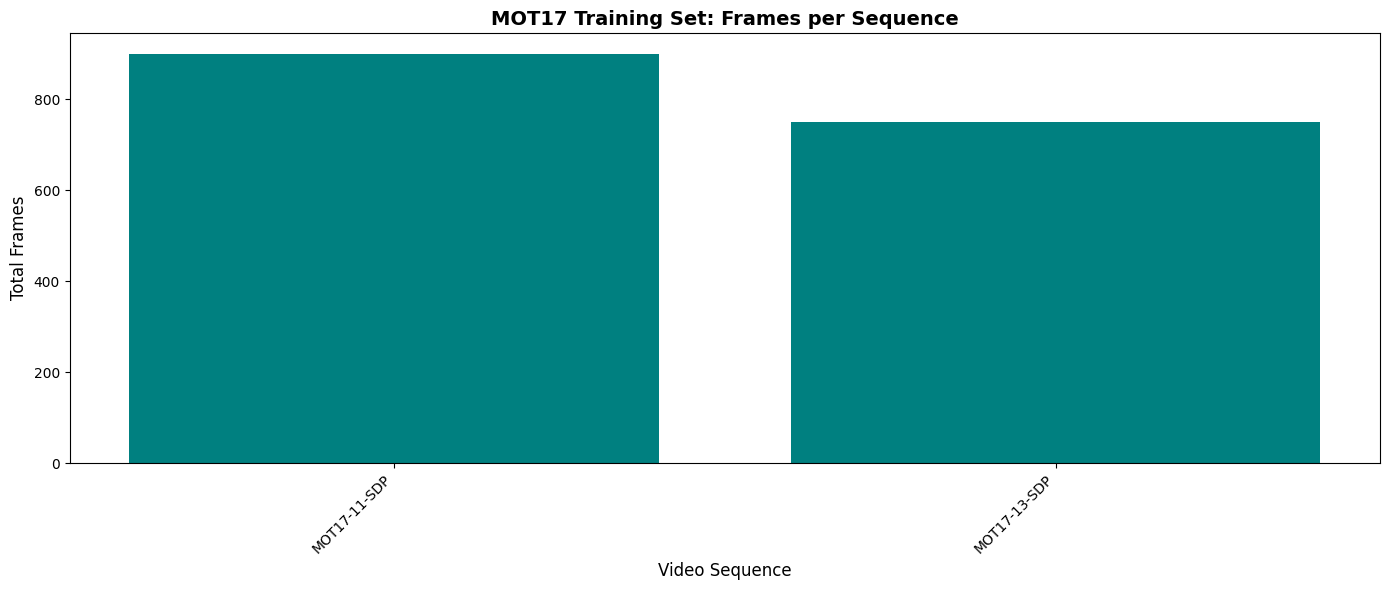


Visualizing First Frame of the First Video...


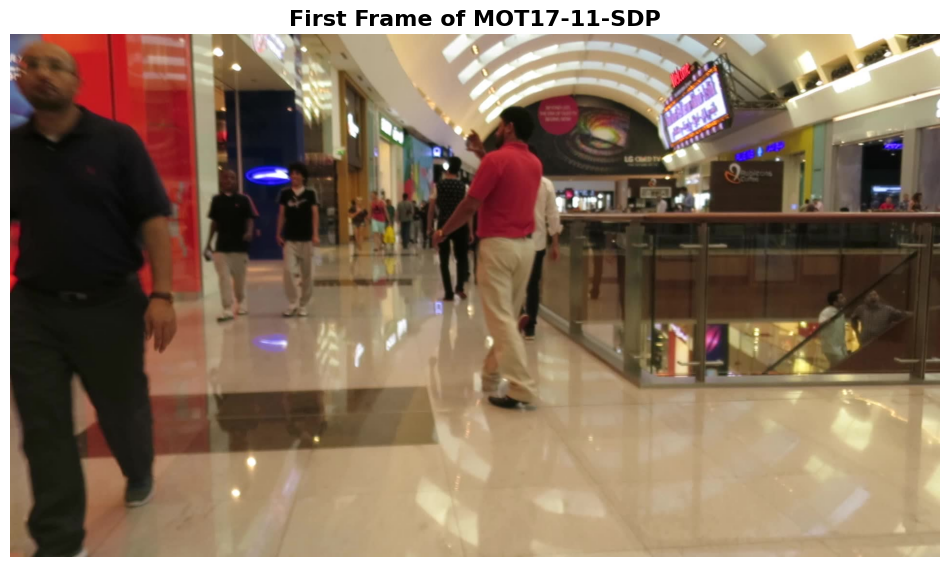

In [ ]:
import sys
import os
import glob
import cv2
import matplotlib.pyplot as plt


sys.path.append('/content/assignment_code')

print("Parsing the MOT17 Training Sequences...")
train_dir = '/content/assignment_code/train'
seq_dirs = sorted(glob.glob(os.path.join(train_dir, 'MOT17-*')))

seq_names, frame_counts = [], []
for seq in seq_dirs:
    seq_name = os.path.basename(seq)
    info_path = os.path.join(seq, 'seqinfo.ini')
    if os.path.exists(info_path):
        with open(info_path, 'r') as f:
            for line in f:
                if line.startswith('seqLength'):
                    frame_counts.append(int(line.split('=')[1].strip()))
                    seq_names.append(seq_name)
                    break

print("Plotting Data Distribution...")
plt.figure(figsize=(14, 6))
plt.bar(seq_names, frame_counts, color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('MOT17 Training Set: Frames per Sequence', fontsize=14, fontweight='bold')
plt.xlabel('Video Sequence', fontsize=12)
plt.ylabel('Total Frames', fontsize=12)
plt.tight_layout()
plt.show()

print("\nVisualizing First Frame of the First Video...")
if len(seq_dirs) > 0:
    first_video_name = os.path.basename(seq_dirs[0])
    first_frame_path = os.path.join(seq_dirs[0], 'img1', '000001.jpg')

    img = cv2.imread(first_frame_path)
    if img is not None:
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f'First Frame of {first_video_name}', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.show()

In [ ]:
import numpy as np

class CustomIOUTracker:
    def __init__(self, iou_threshold=0.3):
        self.iou_threshold = iou_threshold
        self.next_id = 1
        self.trackers = []

    def _compute_iou(self, box1, box2):
        x_left = max(box1[0], box2[0])
        y_top = max(box1[1], box2[1])
        x_right = min(box1[2], box2[2])
        y_bottom = min(box1[3], box2[3])

        if x_right < x_left or y_bottom < y_top:
            return 0.0

        inter_area = (x_right - x_left) * (y_bottom - y_top)
        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
        return inter_area / float(box1_area + box2_area - inter_area)

    def update(self, detections):
        updated_trackers = []
        unmatched_dets = list(range(len(detections)))

        for trk in self.trackers:
            best_iou, best_det_idx = 0.0, -1
            for i in unmatched_dets:
                iou = self._compute_iou(trk['box'], detections[i][:4])
                if iou > best_iou:
                    best_iou, best_det_idx = iou, i

            if best_iou >= self.iou_threshold:
                trk['box'] = detections[best_det_idx][:4]
                trk['score'] = detections[best_det_idx][4]
                trk['cls'] = detections[best_det_idx][5]
                updated_trackers.append(trk)
                unmatched_dets.remove(best_det_idx)

        for i in unmatched_dets:
            det = detections[i]
            updated_trackers.append({
                'box': det[:4], 'id': self.next_id, 'score': det[4], 'cls': det[5]
            })
            self.next_id += 1

        self.trackers = updated_trackers

        outputs = [[t['box'][0], t['box'][1], t['box'][2], t['box'][3], t['id'], t['cls'], t['score']] for t in self.trackers]
        return np.array(outputs) if outputs else np.empty((0, 7))

In [ ]:
import pandas as pd
import motmetrics as mm
from byte.byte_tracker import BYTETracker

def load_frames_and_detections(base_dir):

    img_dir = os.path.join(base_dir, 'img1')
    frames = [cv2.imread(os.path.join(img_dir, f)) for f in sorted(os.listdir(img_dir)) if f.endswith('.jpg')]

    detections = []
    with open(os.path.join(base_dir, 'det/det.txt'), 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            frame, x, y, w, h, score = int(parts[0]), float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5]), float(parts[6])
            if x >= 0 and y >= 0:
                detections.append([frame, x, y, x + w, y + h, score, 0])
    return frames, detections

def track_and_visualize(tracker, frames, detections, output_filename):
    tracked_data = []
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_filename, fourcc, 30.0, (frames[0].shape[1], frames[0].shape[0]))

    for frame_idx, frame in enumerate(frames):
        draw_frame = frame.copy()
        frame_dets = [d for d in detections if d[0] == frame_idx + 1]

        if frame_dets:
            det_array = np.array([d[1:7] for d in frame_dets])
            online_tracks = tracker.update(det_array)

            for track in online_tracks:
                x1, y1, x2, y2, track_id, cls, score = track
                w, h = x2 - x1, y2 - y1
                tracked_data.append([frame_idx + 1, int(track_id), x1, y1, w, h, score, cls])

                cv2.rectangle(draw_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                cv2.putText(draw_frame, f'ID: {int(track_id)}', (int(x1), int(y1)-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        out.write(draw_frame)
    out.release()
    return tracked_data

def evaluate(gt_path, tracked_data):
    gt_df = pd.read_csv(gt_path, header=None, names=["frame", "id", "x", "y", "w", "h", "conf", "class", "visibility"])
    gt_df = gt_df[(gt_df["conf"] != 0) & (gt_df["y"] != -1)]
    track_df = pd.DataFrame(tracked_data, columns=["frame", "id", "x", "y", "w", "h", "conf", "class"])

    acc = mm.MOTAccumulator(auto_id=True)
    for frame in sorted(gt_df["frame"].unique()):
        gt = gt_df[gt_df["frame"] == frame]
        pred = track_df[track_df["frame"] == frame]
        dist = mm.distances.iou_matrix(gt[["x", "y", "w", "h"]].values, pred[["x", "y", "w", "h"]].values, max_iou=0.5)
        acc.update(gt["id"].values, pred["id"].values, dist)

    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=['mota', 'num_switches', 'idp', 'idr', 'idf1'], name="Overall")
    return summary

test_sequence = seq_dirs[0]
print(f"Loading data for {os.path.basename(test_sequence)}...")
frames, detections = load_frames_and_detections(test_sequence)

print("\n1. Running ByteTrack...")
byte_tracker = BYTETracker()
byte_tracks = track_and_visualize(byte_tracker, frames, detections, 'ByteTrack_Output.mp4')
byte_summary = evaluate(os.path.join(test_sequence, 'gt/gt.txt'), byte_tracks)

print("2. Running Custom IOU Tracker...")
iou_tracker = CustomIOUTracker(iou_threshold=0.3)
iou_tracks = track_and_visualize(iou_tracker, frames, detections, 'IOUTrack_Output.mp4')
iou_summary = evaluate(os.path.join(test_sequence, 'gt/gt.txt'), iou_tracks)

print("\n" + "="*60)
print("🏆 FINAL MOTA COMPARISON 🏆")
print("="*60)
print(f"ByteTrack MOTA:  {byte_summary.loc['Overall', 'mota'] * 100:.2f}%")
print(f"IOU Tracker MOTA: {iou_summary.loc['Overall', 'mota'] * 100:.2f}%")
print("="*60)

Loading data for MOT17-11-SDP...

1. Running ByteTrack...
2. Running Custom IOU Tracker...

🏆 FINAL MOTA COMPARISON 🏆
ByteTrack MOTA:  65.13%
IOU Tracker MOTA: 63.55%
